In [8]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [9]:
df=pd.read_csv(r"D:\project of ml\Simple linear regression\Project 1\Data\Ice Cream.csv")


In [10]:
df.head()

,Temperature,Sales
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [11]:
df.shape

(99, 2)

In [12]:
df.isnull().sum()

Temperature    0
Sales          0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  99 non-null     float64
 1   Sales        99 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.7 KB


In [14]:
## Independent feature and dependent feature
X = df[['Temperature']]##independent feature should be in data frame and in 2 dimension
y = df['Sales']## this feature is like 1D array

Text(0, 0.5, 'Sales')

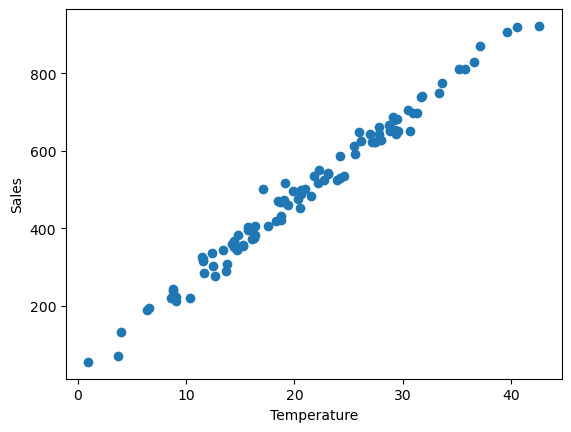

In [15]:
plt.scatter(df['Temperature'],df['Sales'])
plt.xlabel('Temperature')
plt.ylabel('Sales')

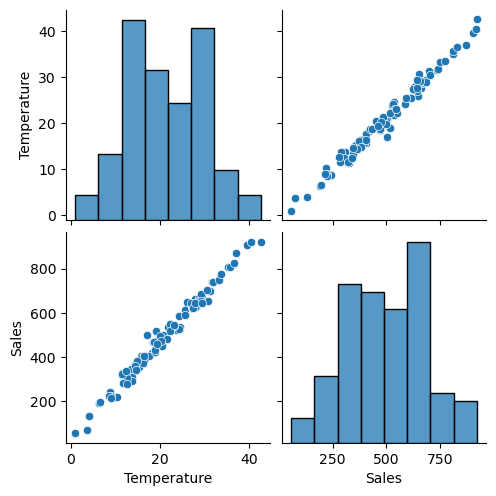

In [16]:
sns.pairplot(df)

In [17]:
X_series=df['Temperature']
np.array(X_series).shape


(99,)

In [18]:
np.array(y).shape

(99,)

In [19]:
## Train and Test Split
from sklearn.model_selection import train_test_split

In [20]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)


In [21]:
X_train.shape

(74, 1)

In [22]:
##Standardlization
from sklearn.preprocessing import StandardScaler

In [23]:
scaler=StandardScaler()
scaler.fit_transform(X_train)

array([[-0.29269273],
       [ 1.17610339],
       [-0.67633351],
       [-1.89302283],
       [-1.57514904],
       [-0.93940147],
       [ 0.35401601],
       [-0.20500341],
       [-0.72017817],
       [-0.72017817],
       [-0.57768302],
       [-0.23788691],
       [ 1.7680063 ],
       [ 0.55131698],
       [ 0.66092863],
       [ 1.61454999],
       [ 1.08841407],
       [ 0.70477329],
       [ 0.90207426],
       [ 0.09094805],
       [-0.53383836],
       [-0.21596458],
       [ 0.77054028],
       [-0.79690632],
       [ 0.32113251],
       [-0.04058594],
       [ 2.37087038],
       [ 1.18706455],
       [-2.18897429],
       [ 0.50747232],
       [-0.78594516],
       [ 0.93495775],
       [ 0.14575387],
       [-1.30111992],
       [ 1.35148203],
       [-0.68729467],
       [-1.15862477],
       [-0.7421005 ],
       [-1.59707137],
       [-0.11731409],
       [ 0.00325872],
       [-1.01612963],
       [-1.02709079],
       [-0.07346943],
       [ 0.8582296 ],
       [-1

In [24]:
X_test=scaler.transform(X_test)
X_test

array([[ 1.38436552],
       [ 0.23344319],
       [-1.30111992],
       [ 0.94591892],
       [-0.17211992],
       [ 0.91303542],
       [-0.04058594],
       [-0.23788691],
       [-1.03805196],
       [ 0.39786067],
       [-0.62152768],
       [ 2.14068591],
       [ 1.06649174],
       [-0.57768302],
       [-0.24884807],
       [-1.02709079],
       [ 0.18959853],
       [-0.22692574],
       [ 0.92399659],
       [ 0.70477329],
       [ 1.13225873],
       [-0.90651798],
       [ 0.05806455],
       [-0.2707704 ],
       [-0.42422671]])

In [25]:
##Apply simple linear regression
from sklearn.linear_model import LinearRegression

In [26]:
regression=LinearRegression()

In [27]:
regression.fit(X_train,y_train)

LinearRegression()

In [28]:
print("Coefficent and slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficent and slope: [21.80774536]
Intercept: 37.55055074606213


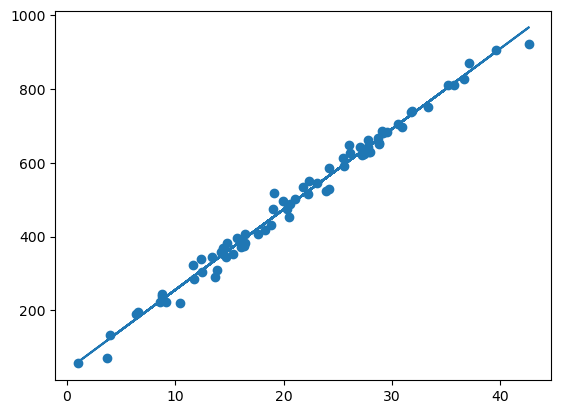

In [29]:
## Plot training data plot bestfit line
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [30]:
## Prediction for the test data
y_pred=regression.predict(X_test)

f:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [31]:
## Performance metrices
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [32]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

245576.76892345052
475.15501634069636
495.5570289315353


In [33]:
from sklearn.metrics import r2_score

In [34]:
score=r2_score(y_test,y_pred)
print(score)

-8.745706377022477


In [35]:
## OLS linear regression
import statsmodels.api as sm

In [36]:
model=sm.OLS(y_train,X_train).fit()

In [37]:
prediction=model.predict(X_test)
print(prediction)

[ 32.27430063   5.44236013 -30.33356053  22.05260901  -4.01270461
  21.28598214  -0.94619713  -5.54595836 -24.20054556   9.27549449
 -14.48993852  49.90671867  24.86357421 -13.46776936  -5.80150065
 -23.94500327   4.42019097  -5.29041607  21.54152443  16.43067862
  26.39682795 -21.13403807   1.35368348  -6.31258523  -9.8901773 ]


In [38]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                  Sales   R-squared (uncentered):                   0.998
Model:                            OLS   Adj. R-squared (uncentered):              0.998
Method:                 Least Squares   F-statistic:                          3.131e+04
Date:                Wed, 28 Jan 2026   Prob (F-statistic):                    7.06e-98
Time:                        09:19:47   Log-Likelihood:                         -345.36
No. Observations:                  74   AIC:                                      692.7
Df Residuals:                      73   BIC:                                      695.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                  coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------

In [39]:
## Predicyion for new data
regression.predict([[50]])

f:\anaconda\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([1127.93781859])